<a href="https://colab.research.google.com/github/MeLBiN122/AI-ML/blob/main/T2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder,MinMaxScaler,StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import skew
import numpy as np
from sklearn.preprocessing import PowerTransformer

In [ ]:
df = pd.read_csv("/content/Walmart Data Analysis and Forcasting.csv")

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


In [ ]:
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day

In [ ]:
df = df.drop('Date', axis=1)

<Axes: >

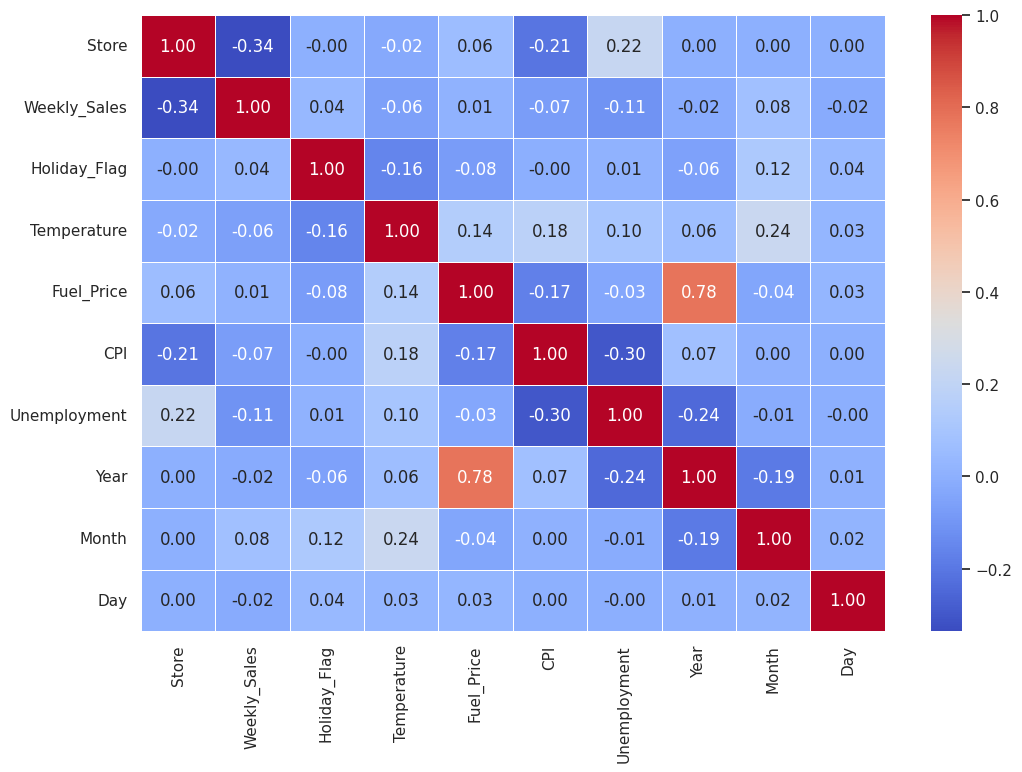

In [ ]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)

In [ ]:
sns.set(style='whitegrid')

In [ ]:
standard_scaler = StandardScaler()

df[['Store','Weekly_Sales','Holiday_Flag','Temperature','Fuel_Price','CPI','Unemployment','Year','Month','Day']] = standard_scaler.fit_transform(
    df[['Store','Weekly_Sales','Holiday_Flag','Temperature','Fuel_Price','CPI','Unemployment','Year','Month','Day']])

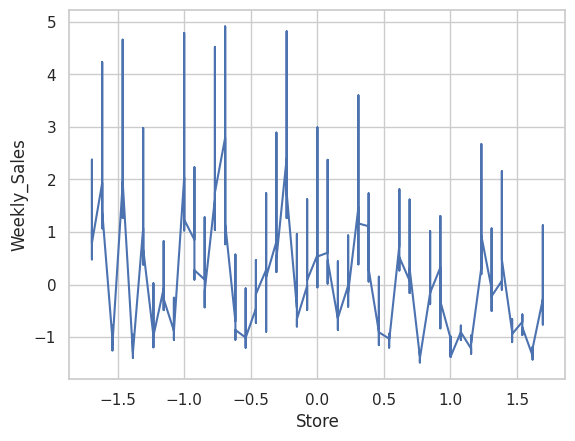

In [ ]:
plt.plot(df['Store'], df['Weekly_Sales'])
plt.xlabel('Store')
plt.ylabel('Weekly_Sales')
plt.show()

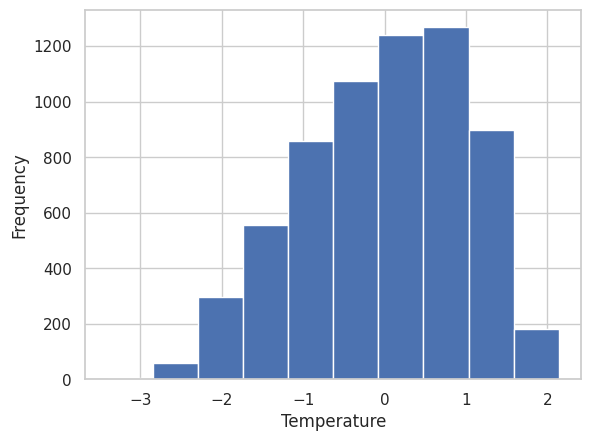

In [ ]:
plt.hist(df['Temperature'].dropna(), bins=10)
plt.xlabel('Temperature')
plt.ylabel('Frequency')
plt.show()

In [ ]:
X = df.drop(columns=["Weekly_Sales"])
y = df["Weekly_Sales"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)

rmse = mean_squared_error(y_test, y_pred) ** 0.5

print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

R² Score: 0.1555
RMSE: 0.9243


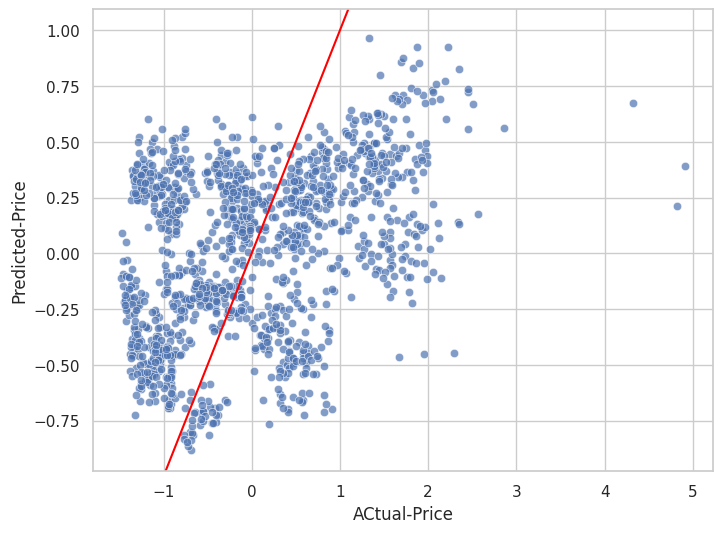

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test,y=y_pred,alpha=0.7)
plt.xlabel('ACtual-Price')
plt.ylabel('Predicted-Price')
plt.axline([0,0],[1,1],color='red',linestyle='solid')
plt.show()

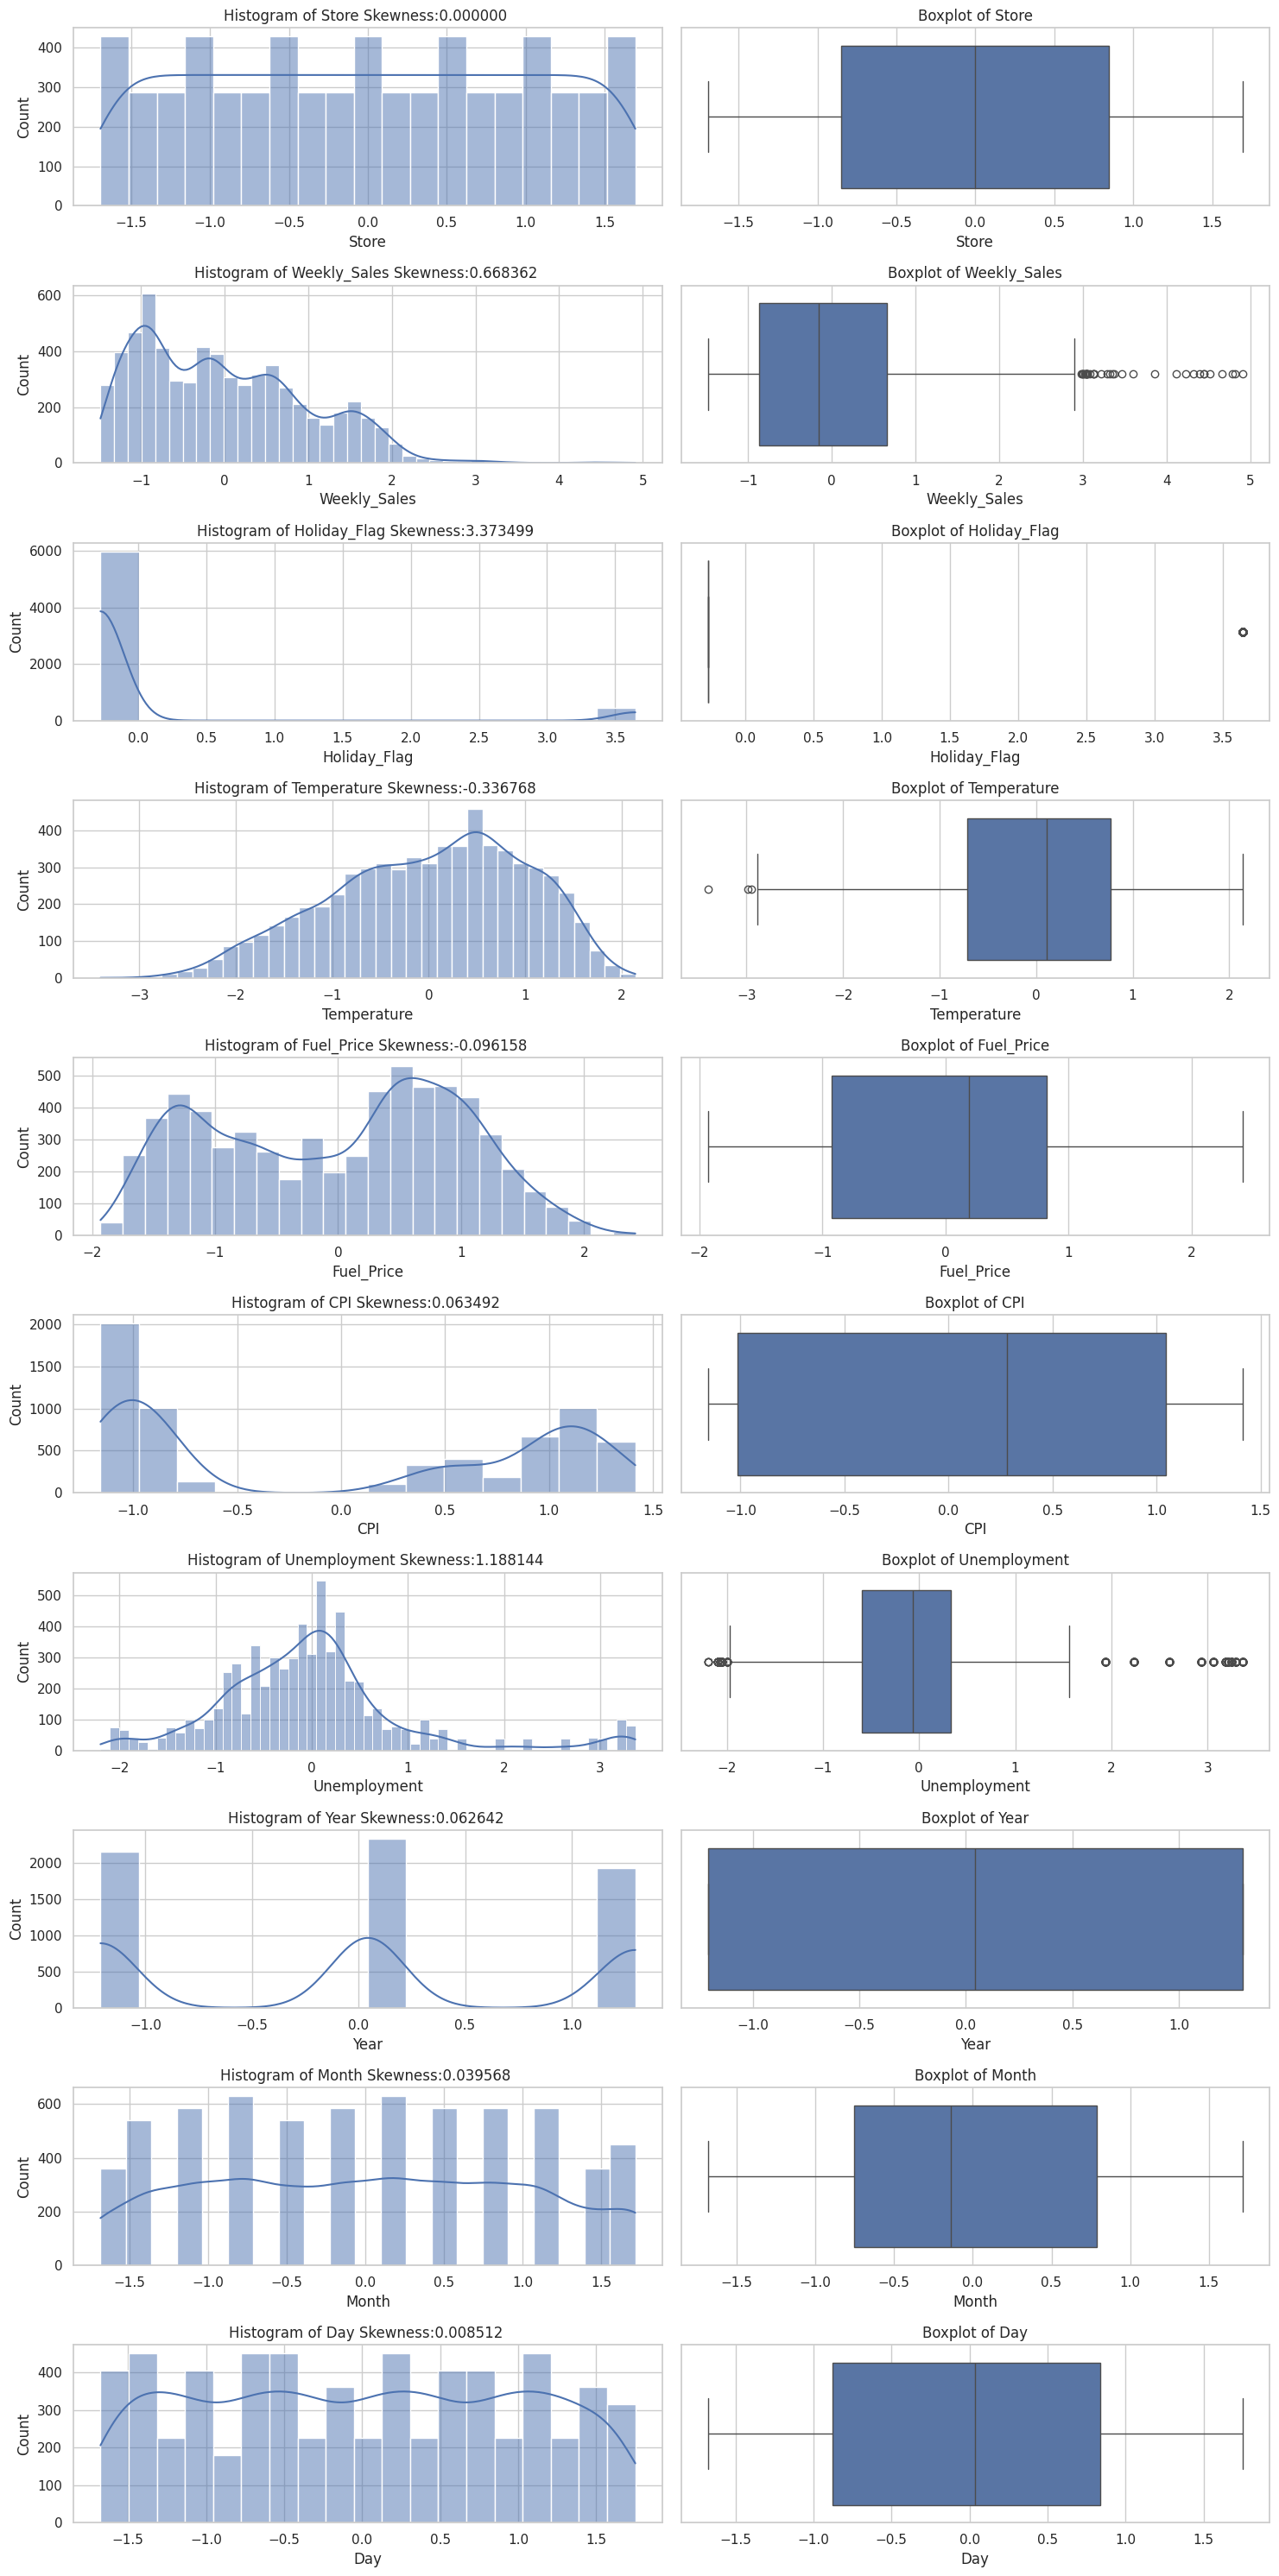

In [ ]:
skewness = df.skew()
num_cols=len(df.columns)
plt.figure(figsize=(15,num_cols*3))

for i,col in enumerate(df.columns):
    plt.subplot(num_cols,2,2*i+1)
    sns.histplot(df[col],kde=True)
    plt.title(f'Histogram of {col} Skewness:{skewness[col]:2f} ')

    plt.subplot(num_cols,2,2*i+2)
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

In [ ]:
skewed_cols = df.skew().abs()
highly_skewed = skewed_cols[skewed_cols > 1].index
neg_skewed = skewed_cols[skewed_cols < 1].index
print(highly_skewed)
print(neg_skewed)

Index(['Holiday_Flag', 'Unemployment'], dtype='object')
Index(['Store', 'Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI', 'Year',
       'Month', 'Day'],
      dtype='object')


In [ ]:
highly_skewed = highly_skewed.drop('Unemployment')

In [ ]:
df[highly_skewed] = df[highly_skewed].apply(lambda x : np.log1p(x))

In [ ]:
pt = PowerTransformer(method='yeo-johnson')
df[neg_skewed] = pt.fit_transform(df[neg_skewed])

In [ ]:
X = df.drop(columns=["Weekly_Sales"])
y = df["Weekly_Sales"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)

rmse = mean_squared_error(y_test, y_pred) ** 0.5

print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

R² Score: 0.1451
RMSE: 0.9342


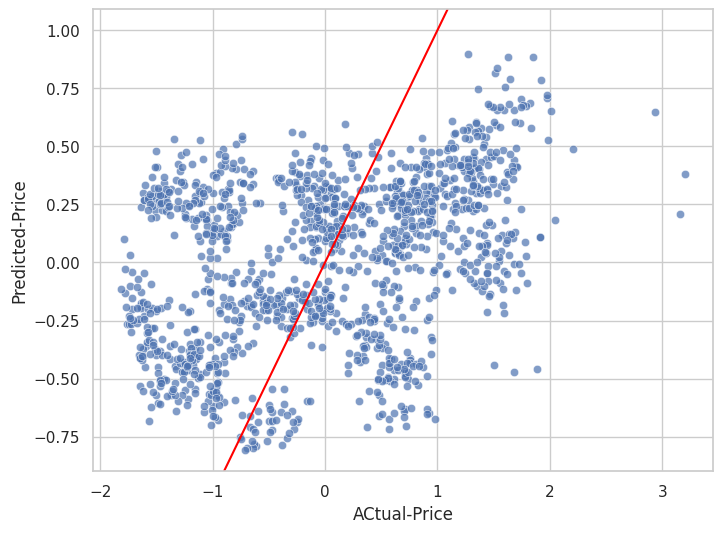

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test,y=y_pred,alpha=0.7)
plt.xlabel('ACtual-Price')
plt.ylabel('Predicted-Price')
plt.axline([0,0],[1,1],color='red',linestyle='solid')
plt.show()